# Домашнее задание 3

# 1

## Теоретические вопросы

1) Функция потерь:
$$
L(c)=\sum_{i=1}^n (y_i - c)^2 \to \min_c.
$$ 
Минимизируем ее: $L'(c) = -2\sum_{i=1}^n (y_i - c) = 0 \Rightarrow n c = \sum_{i=1}^n y_i$. Таким образом
$$ \bar y = \frac{1}{n}\sum_{i=1}^n y_i.
$$ 
То есть оптимальная константа равна среднему выборки.

2) Пусть прямая по МНК имеет вид $y = a x + b$. Тогда:
$$ a = \frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2},\qquad b=\bar y - a\bar x.
$$ 
Подставляя $x=\bar x$, получаем $a\bar x + b = a\bar x + (\bar y - a\bar x) = \bar y$, т.е. прямая проходит через $(\bar x,\bar y)$. Аналогично в многомерном случае МНК даёт $\hat y = X\hat w$; средние по признакам и по откликам связаны так, что регрессор проходит через точку средних.

## Практическое задание

Datasets: ['I' 'II' 'III' 'IV']


{'I': {'var_x': np.float64(11.0),
  'var_y': np.float64(4.127269090909091),
  'pearson_r': np.float64(0.81642051634484)},
 'II': {'var_x': np.float64(11.0),
  'var_y': np.float64(4.127629090909091),
  'pearson_r': np.float64(0.8162365060002428)},
 'III': {'var_x': np.float64(11.0),
  'var_y': np.float64(4.12262),
  'pearson_r': np.float64(0.8162867394895984)},
 'IV': {'var_x': np.float64(11.0),
  'var_y': np.float64(4.123249090909091),
  'pearson_r': np.float64(0.8165214368885028)}}

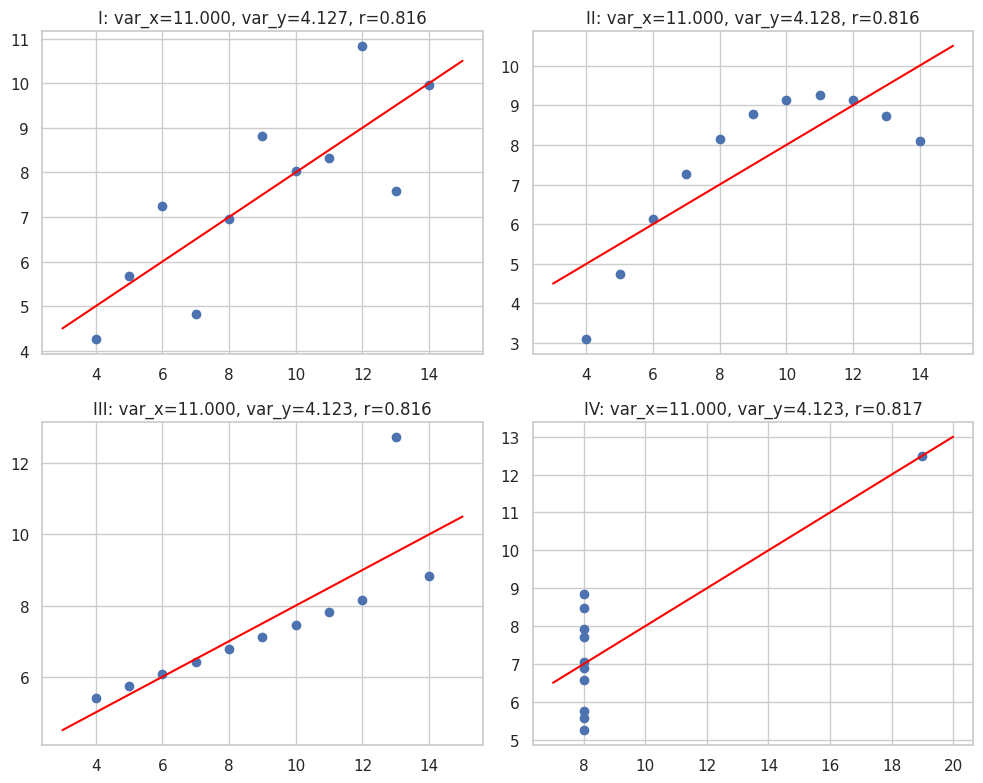

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
ans = sns.load_dataset('anscombe')
datasets = ans['dataset'].unique()
print('Datasets:', datasets)

stats = {}
fig, axes = plt.subplots(2,2, figsize=(10,8))
axes = axes.ravel()
for i, d in enumerate(datasets):
    df = ans[ans['dataset']==d]
    x = df['x'].values
    y = df['y'].values
    sx = np.var(x, ddof=1)
    sy = np.var(y, ddof=1)
    r = np.corrcoef(x,y)[0,1]
    stats[d] = {'var_x': sx, 'var_y': sy, 'pearson_r': r}
    ax = axes[i]
    ax.scatter(x,y)
    # plot OLS line
    A = np.vstack([x, np.ones_like(x)]).T
    a,b = np.linalg.lstsq(A,y, rcond=None)[0]
    xs = np.linspace(x.min()-1, x.max()+1, 100)
    ax.plot(xs, a*xs + b, color='red')
    ax.set_title(f"{d}: var_x={sx:.3f}, var_y={sy:.3f}, r={r:.3f}")

plt.tight_layout()

# show computed stats
stats


# 2

## Практическая часть

In [2]:
import numpy as np
rng = np.random.default_rng(0)
n, p = 100, 4
X = rng.normal(size=(n,p))
w_true = np.array([1.2, -0.5, 0.3, 2.0])
y = X @ w_true + 0.7 + rng.normal(scale=0.1, size=n)

# Approach 1: centralize columns of X (and center y)
Xc = X - X.mean(axis=0)
yc = y - y.mean()
wc = np.linalg.lstsq(Xc, yc, rcond=None)[0]
intercept_from_center = y.mean() - X.mean(axis=0) @ wc

# Approach 2: add column of ones
X1 = np.hstack([X, np.ones((n,1))])
w1 = np.linalg.lstsq(X1, y, rcond=None)[0]

print('wc (centered coefficients):', wc)
print('intercept_from_center:', intercept_from_center)
print('w1 (coeffs + intercept):', w1)
print('\nDifference coefficients:', np.linalg.norm(w1[:-1] - wc))
print('Difference intercept:', abs(w1[-1] - intercept_from_center))

wc (centered coefficients): [ 1.19131558 -0.48043338  0.30558723  1.99178688]
intercept_from_center: 0.7027609288785374
w1 (coeffs + intercept): [ 1.19131558 -0.48043338  0.30558723  1.99178688  0.70276093]

Difference coefficients: 4.7480696664033085e-15
Difference intercept: 9.992007221626409e-16


# 3

Рассмотрим недоопределённую систему $X w = y$, где $X$ имеет размер $n\times p$ и полную строковую ранговость ($n<p$), т.е. система имеет бесконечно много решений при совместности. Требуется найти решение с минимальной $\ell_2$-нормой:
$$
\min_w \|w\|_2 \quad\text{т.ч. } Xw=y.
$$ 
Минимум по $w$ достигается при условии существования множителя $\lambda$ размерности $n$:
$$
\mathcal{L}(w,\lambda)=\frac{1}{2}w^T w + \lambda^T (Xw - y).
$$
Стационарные условия: $w + X^T \lambda = 0$ и $Xw = y$. Подставим первое равенство $w = -X^T \lambda$ во второе:
$$X (-X^T \lambda) = y \quad\Rightarrow\quad -(X X^T)\lambda = y.
$$ 
При предположении полной ранговости $X X^T$ обратима, значит $\lambda = -(X X^T)^{-1} y$, и
$$w = X^T (X X^T)^{-1} y.
$$
Это и есть **правый псевдообратный** оператор: $w = X^{+}_\text{right} y$, где $X^{+}_\text{right} = X^T (X X^T)^{-1}$.

# 4

## Теоретический вопрос 1

Пусть
$X = V \sqrt{\Lambda}\, U^{T}, \quad \Lambda = \mathrm{diag}(\lambda_1, \dots, \lambda_F), \quad \lambda_1 \ge \cdots \ge \lambda_F \ge 0$,
— сингулярное разложение матрицы X.

При усечении оставляем только $\tilde F$ наибольших сингулярных чисел:
$\tilde \Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_{\tilde F},0,\dots,0),
\quad \tilde X = V \sqrt{\tilde \Lambda}\, U^{T}.$

Ошибка аппроксимации:
$$
\|X - \tilde X\|_F^2 = \|X\|_F^2 + \|\tilde X\|_F^2 - 2\langle X, \tilde X \rangle.
$$

$$
\|X\|F^2 = \mathrm{tr}(X^T X) = \mathrm{tr}(U \Lambda U^T) = \mathrm{tr}(\Lambda) = \sum_{i=1}^F \lambda_i,
$$

$$
\|\tilde X\|F^2 = \mathrm{tr}(\tilde \Lambda) = \sum_{i=1}^{\tilde F} \lambda_i.
$$

Скалярное произведение:
$$
\langle X, \tilde X \rangle = \mathrm{tr}(X^T \tilde X)
= \mathrm{tr}\big(U \sqrt{\Lambda}\, V^T V \sqrt{\tilde \Lambda}\, U^T\big)
= \mathrm{tr}(\sqrt{\Lambda}\, \sqrt{\tilde \Lambda})
= \sum_{i=1}^{\tilde F} \lambda_i.
$$
$$
\|X - \tilde X\|F^2 =
\sum_{i=1}^F \lambda_i + \sum_{i=1}^{\tilde F}\lambda_i - 2\sum_{i=1}^{\tilde F}\lambda_i
= \sum_{i=\tilde F+1}^F \lambda_i.
$$
Таким образом:
$$
\frac{1}{l}\|X - \tilde X\|F^2 = \sum_{i=\tilde F+1}^F \lambda_i.
$$

## Теоретический вопрос 2

Нужно показать: сингулярный вектор u, отвечающий наибольшему сингулярному числу матрицы X, решает задачу
$$
u = \arg \max_{\|u\|=1} (Xu)^2.
$$

Преобразуем:
$$
(Xu)^2 = \|Xu\|^2 = u^T (X^T X) u.
$$

Матрица $X^T X$ симметрична и положительно полуопределённая. Максимум выражения $u^T (X^T X) u$ при $\|u\|=1$ равен наибольшему собственному значению этой матрицы (принцип Релея).

Из SVD:
$$
X^T X = U \Lambda U^T,
$$
где собственные значения — $\lambda_i$, а собственные векторы — столбцы U.
Следовательно, максимум достигается при $u = u_1$ (первый столбец U), соответствующем наибольшему $\lambda_1$.

Это и есть сингулярный вектор, отвечающий наибольшему сингулярному числу матрицы X.

## Практическая часть

k=1: error (fro^2)=329.332380, sum remaining sigma^2=329.332380
k=2: error (fro^2)=161.082232, sum remaining sigma^2=161.082232
k=3: error (fro^2)=0.000000, sum remaining sigma^2=0.000000


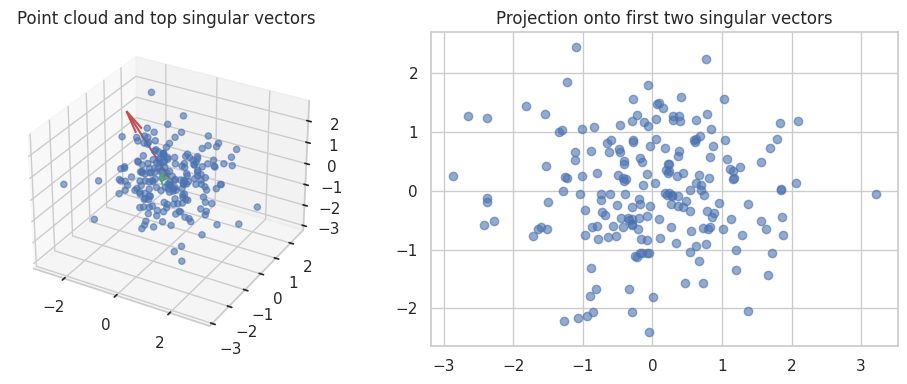

In [3]:
import numpy as np
        
A = np.random.default_rng(0).normal(size=(6,6))
A = 0.5*(A + A.T)

N = 200
X = np.random.default_rng(1).normal(size=(N,3))
Xc = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)

for k in [1,2,3]:
    Xk = U[:,:k] @ np.diag(s[:k]) @ Vt[:k,:]
    err = np.linalg.norm(Xc - Xk, 'fro')**2
    err_singulars = np.sum(s[k:]**2)
    print(f'k={k}: error (fro^2)={err:.6f}, sum remaining sigma^2={err_singulars:.6f}')

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(Xc[:,0], Xc[:,1], Xc[:,2], alpha=0.6)
# plot first two right singular vectors scaled
origin = np.zeros(3)
for i in range(2):
    v = Vt[i,:]
    ax1.quiver(origin[0], origin[1], origin[2], v[0], v[1], v[2], length=3, color=['r','g'][i])
ax1.set_title('Point cloud and top singular vectors')

proj = Xc @ Vt[:2,:].T
ax2 = fig.add_subplot(122)
ax2.scatter(proj[:,0], proj[:,1], alpha=0.6)
ax2.set_title('Projection onto first two singular vectors')
plt.tight_layout()


# 5

## Теоретический вопрос 1

Пусть $u\in\mathbb{R}^2$ — единичный вектор ($\|u\|_2=1$). Рассмотрим прямую $a_u=\{t u:\; t\in\mathbb{R}\}$. Для каждой точки $x_i\in\mathbb{R}^2$ (строка матрицы $X$) разложим $x_i$ по ортонормальному базису $\{u,w\}$, где $w$ — единичный вектор, ортогональный $u$:
$$
x_i = (u^T x_i) u + (w^T x_i) w.
$$
Длина перпендикуляра от $x_i$ до прямой $a_u$ равна $|w^T x_i|$, следовательно квадрат расстояния:
$$
\operatorname{d}^2(x_i,a_u) = (w^T x_i)^2.
$$
Поскольку $u$ и $w$ ортонормальны,
$$
\|x_i\|_2^2 = (u^T x_i)^2 + (w^T x_i)^2.
$$
Суммируя по $i$:
\begin{align*}
\sum_{i=1}^N \operatorname{d}^2(x_i,a_u)
&= \sum_{i=1}^N (w^T x_i)^2 \\
&= \sum_{i=1}^N \big(\|x_i\|_2^2 - (u^T x_i)^2\big) \\
&= \sum_{i=1}^N \|x_i\|_2^2 \;-\; \sum_{i=1}^N (u^T x_i)^2.
\end{align*}

Заметим, что первая слагаемая $\sum_i\|x_i\|_2^2$ не зависит от выбора $u$. Следовательно минимизация суммы квадратов расстояний до прямой $a_u$ эквивалентна максимизации суммы квадратов проекций $\sum_i (u^T x_i)^2$:
$$
\min_{\|u\|=1} \sum_{i=1}^N \operatorname{d}^2(x_i,a_u)
\quad\Longleftrightarrow\quad
\max_{\|u\|=1} \sum_{i=1}^N (u^T x_i)^2.
$$

Запишем сумму квадратов проекций в матричной форме:
$$
\sum_{i=1}^N (u^T x_i)^2 = \sum_{i=1}^N u^T x_i x_i^T u = u^T\Big(\sum_{i=1}^N x_i x_i^T\Big) u = u^T C u,
$$
то есть задача эквивалентна
$$
\max_{\|u\|_2=1} u^T C u.
$$
Максимум этой квадратичной формы на единичной сфере достигается на собственном векторе $v_1$ матрицы $C = X^T X$, соответствующем наибольшему собственному значению $\lambda_1$. Поскольку $\lambda_1=\sigma_1^2$, мы получаем
$$
v_1 = \arg\max_{\|u\|_2=1} \|X u\|_2^2,
\qquad \max_{\|u\|=1} \|X u\|_2^2 = \sigma_1^2.
$$

ч.т.д

## Теоретический вопрос 2

Для набора точечных масс $m_i$ в точках $r_i$ (относительно начала координат), тензор инерции $J$ (матрица $3\times3$) определяется как
$$
J := \sum_{i=1}^n m_i \big(\|r_i\|_2^2 I_3 - r_i r_i^T\big),
$$
где $I_3$ — единичная матрица $3\times3$. Собственные значения тензора $J$ — это главные моменты инерции (относительно данного начала координат), собственные векторы — главные оси инерции.

БОО положим для всех масс $m_i\equiv 1$ (можно привести к этому случаю путём замены каждой строки $r_i^T$ на $\sqrt{m_i}\,r_i^T$). Тогда
$$
C := X^T X = \sum_{i=1}^n r_i r_i^T.
$$
Рассмотрим след $t := \operatorname{tr}(C)$. Поскольку $\operatorname{tr}(r_i r_i^T) = \|r_i\|_2^2$, имеем
$$
t = \operatorname{tr}(C) = \sum_{i=1}^n \|r_i\|_2^2.
$$
Запишем тензор инерции $J$:
$$
J = \sum_{i=1}^n \big(\|r_i\|_2^2 I_3 - r_i r_i^T\big)
= \Big(\sum_{i=1}^n \|r_i\|_2^2\Big) I_3 - \sum_{i=1}^n r_i r_i^T
= t I_3 - C.
$$

Таким образом
$$
J = t I_3 - C
$$

Пусть теперь $(v,\lambda)$ — собственный вектор/собственное значение для матрицы $C$:
$$
C v = \lambda v.
$$
Тогда действуя на $v$ матрицей $J$:
$$
J v = (t I_3 - C)v = t v - C v = t v - \lambda v = (t-\lambda) v.
$$
Значит $v$ — также собственный вектор матрицы $J$, и соответствующее собственное значение (главный момент инерции вдоль этого направления) равно $t-\lambda$.

Обратно, если $(v,\mu)$ — собственная пара для $J$, то
$$
(t I_3 - C) v = \mu v \quad\Longrightarrow\quad C v = (t-\mu) v,
$$
то есть $v$ — собственный вектор $C$ с собственным значением $\lambda = t-\mu$.

Сингулярные числа матрицы $X$ равны $\sigma_j=\sqrt{\lambda_j}$, поэтому окончательно получаем, что момент инерции вдоль направления $v_j$ равен:
$$
\mu_j = t - \lambda_j = t - \sigma_j^2.
$$

# Практическая часть

In [4]:
import numpy as np

rng = np.random.default_rng(2)
N = 200
base_dir = np.array([2.0, 1.0])
base_dir = base_dir / np.linalg.norm(base_dir)
coords = rng.normal(size=(N,2))
#stretch
coords = coords @ np.array([[2.0,0],[0,0.5]])
#center
X = coords - coords.mean(axis=0)

#first right singular vector
U,s,Vt = np.linalg.svd(X, full_matrices=False)
u1 = Vt[0,:]

#objective for many random directions
def objective(u):
    u = np.array(u)
    u = u / np.linalg.norm(u)
    return np.sum((X @ u)**2)

objs = []
dirs = []
for theta in np.linspace(0, 2*np.pi, 360):
    u = np.array([np.cos(theta), np.sin(theta)])
    dirs.append(u)
    objs.append(objective(u))

max_idx = np.argmax(objs)
best_u = dirs[max_idx]
print('Angle of argmax (deg):', np.degrees(np.arctan2(best_u[1], best_u[0])))
print('Angle of u1 (deg):', np.degrees(np.arctan2(u1[1], u1[0])))
print('Max objective vs objective(u1):', objs[max_idx], objective(u1))


Angle of argmax (deg): 1.0027855153203342
Angle of u1 (deg): -178.9707729667586
Max objective vs objective(u1): 761.6340376405091 761.6341885557899


Text(0.5, 1.0, 'Cloud and principal direction')

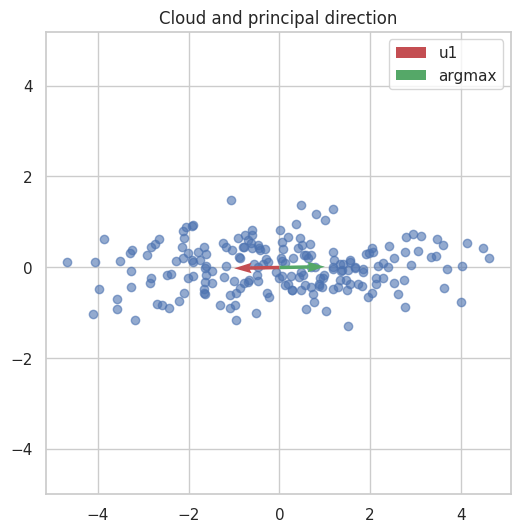

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.6)
origin = np.array([0,0])
plt.quiver(0,0,u1[0],u1[1], angles='xy', scale_units='xy', scale=1, color='r', label='u1')
plt.quiver(0,0,best_u[0],best_u[1], angles='xy', scale_units='xy', scale=1, color='g', label='argmax')
plt.legend(); plt.axis('equal'); plt.title('Cloud and principal direction')